<a href="https://colab.research.google.com/github/Fibukuntomiwa/AI-Tutorial/blob/Assignment-4/Assignment_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score


data = pd.read_excel("/content/Raisin_Dataset.xlsx")

df = pd.DataFrame(data)
print(df)



      Area  MajorAxisLength  MinorAxisLength  Eccentricity  ConvexArea  \
0    87524       442.246011       253.291155      0.819738       90546   
1    75166       406.690687       243.032436      0.801805       78789   
2    90856       442.267048       266.328318      0.798354       93717   
3    45928       286.540559       208.760042      0.684989       47336   
4    79408       352.190770       290.827533      0.564011       81463   
..     ...              ...              ...           ...         ...   
895  83248       430.077308       247.838695      0.817263       85839   
896  87350       440.735698       259.293149      0.808629       90899   
897  99657       431.706981       298.837323      0.721684      106264   
898  93523       476.344094       254.176054      0.845739       97653   
899  85609       512.081774       215.271976      0.907345       89197   

       Extent  Perimeter    Class  
0    0.758651   1184.040  Kecimen  
1    0.684130   1121.786  Kecimen  
2  

In [30]:

# Initialize Logistic Regression model
# Using solver='liblinear' which is good for small datasets and supports L1/L2 penalties
model = LogisticRegression(random_state=7, solver='liblinear')

# Train the model on the training data
model.fit(X_train, y_train)

# Predict on the test data
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy on the test set: {accuracy:.2f}")

# Perform 5-Fold Cross-Validation on the training set to get a more robust estimate of performance
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=7)
cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')

print(f"Cross-validation accuracies: {cv_scores}")
print(f"Average cross-validation accuracy: {cv_scores.mean():.2f}")

if accuracy >= 0.81:
    print("Achieved at least 81% accuracy on the test sample!")
else:
    print("Accuracy on test sample is below 81%. Consider further optimization.")

Accuracy on the test set: 0.90
Cross-validation accuracies: [0.83333333 0.86805556 0.88194444 0.875      0.86805556]
Average cross-validation accuracy: 0.87
Achieved at least 81% accuracy on the test sample!


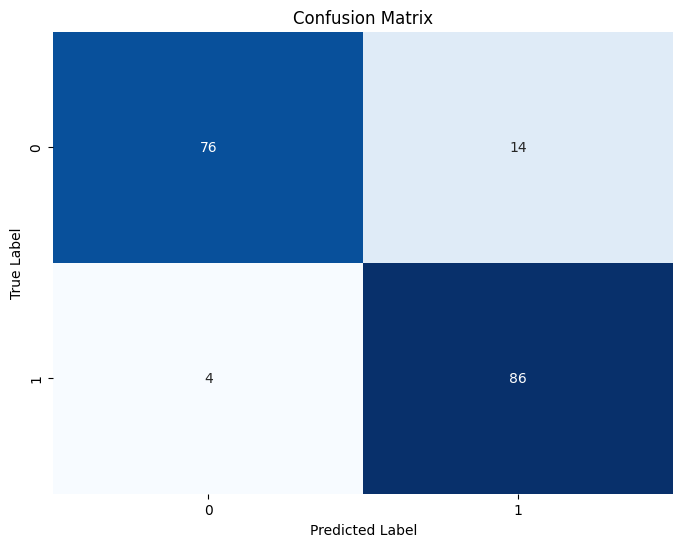


Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.84      0.89        90
           1       0.86      0.96      0.91        90

    accuracy                           0.90       180
   macro avg       0.91      0.90      0.90       180
weighted avg       0.91      0.90      0.90       180



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display the confusion matrix using seaborn heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# Generate and print the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))